In [1]:
!pip -q install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print("Train samples:", len(train_dataset))

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Train samples: 50000


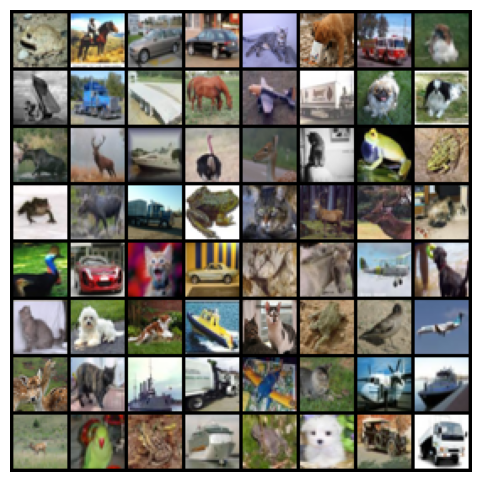

In [3]:
images, _ = next(iter(train_loader))

plt.figure(figsize=(6,6))
grid = torchvision.utils.make_grid(images[:64], nrow=8, normalize=True)
plt.imshow(np.transpose(grid.cpu(), (1,2,0)))
plt.axis("off")
plt.show()

In [4]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(True)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = EncoderDecoder().to(device)

In [5]:
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

epochs = 15
train_losses = []

In [6]:
model.train()

for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

Epoch [1/15] Loss: 0.1652
Epoch [2/15] Loss: 0.1014
Epoch [3/15] Loss: 0.0849
Epoch [4/15] Loss: 0.0757
Epoch [5/15] Loss: 0.0695
Epoch [6/15] Loss: 0.0650
Epoch [7/15] Loss: 0.0616
Epoch [8/15] Loss: 0.0586
Epoch [9/15] Loss: 0.0561
Epoch [10/15] Loss: 0.0542
Epoch [11/15] Loss: 0.0523
Epoch [12/15] Loss: 0.0508
Epoch [13/15] Loss: 0.0494
Epoch [14/15] Loss: 0.0482
Epoch [15/15] Loss: 0.0470


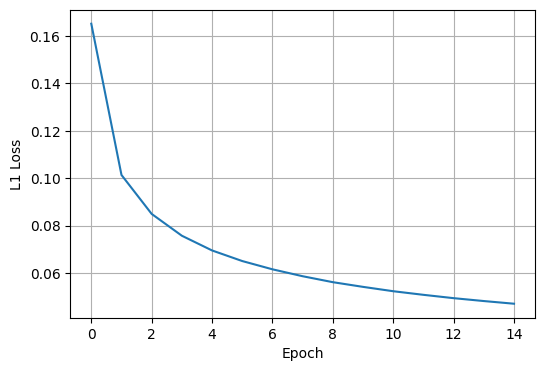

In [7]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.grid(True)
plt.savefig("baseline_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

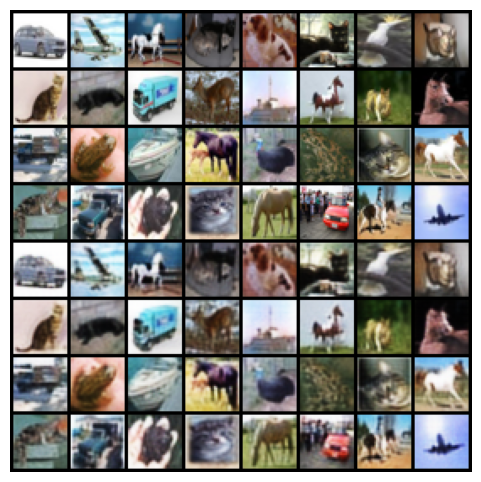

In [8]:
model.eval()

with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images.to(device)
    outputs = model(images)

    comparison = torch.cat([images[:32], outputs[:32]])

plt.figure(figsize=(6,6))
grid = torchvision.utils.make_grid(comparison.cpu(), nrow=8, normalize=True)
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.savefig("baseline_translation_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
torch.save(model.state_dict(), "baseline_encoder_decoder.pth")
print("Model saved.")

Model saved.
